In [93]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import tldextract
from urllib.parse import urlparse,urlsplit
import re
from collections import Counter
from scipy.stats import entropy
import ipaddress

pd.set_option('display.max_colwidth', None)

***Dataset from:*** *https://www.kaggle.com/datasets/elifzelik/phishing-url-features-dataset?select=final_dataset.csv*

## ***Load Dataset and uderstand it***

In [2]:
# Load the dataset
df = pd.read_csv('final_dataset_all_features.csv')

In [3]:
# Get a look at it
df.head()

,url,label,url_length,domain_length,hostname_length,path_length,first_dir_length,tld_length,tld_length_domain,url_depth,...,whois_success,domain_age_days,expiration_days,creation_year,domain_is_recent,domain_registered_before_2020,registrar_valid,name_servers_count,is_privacy_protected,whois_missing
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg1e0h2f/qiye,1,57,7,24,26,3,3,3,3,...,1.0,5484.0,359.0,2010.0,0.0,1.0,1.0,2.0,0.0,0
1,https://*f003.backblazeb2.com*/file/pesosi/home.html,1,52,4,22,22,4,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,http://0-docusign-secured-843439-1-srs09.replit.app/,1,52,6,44,1,0,3,3,0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
3,http://0-olx.1850943.xyz/,1,25,7,17,1,0,3,3,0,...,1.0,272.0,93.0,2025.0,1.0,0.0,1.0,2.0,0.0,0
4,http://0.0.0.0forum.cryptonight.net,1,35,11,28,0,0,3,3,0,...,1.0,475.0,254.0,2024.0,0.0,0.0,1.0,2.0,0.0,0


In [4]:
# Get the shape of the image
rows,columns = df.shape
print(f'Number of rows: {rows}\nNumber of columns: {columns}')

Number of rows: 579920
Number of columns: 76


In [5]:
# Get header informations
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 579920 entries, 0 to 579919
Data columns (total 76 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   url                            579920 non-null  str    
 1   label                          579920 non-null  int64  
 2   url_length                     579920 non-null  int64  
 3   domain_length                  579920 non-null  int64  
 4   hostname_length                579920 non-null  int64  
 5   path_length                    579920 non-null  int64  
 6   first_dir_length               579920 non-null  int64  
 7   tld_length                     579920 non-null  int64  
 8   tld_length_domain              579920 non-null  int64  
 9   url_depth                      579920 non-null  int64  
 10  query_length                   579920 non-null  int64  
 11  path_segments_count            579920 non-null  int64  
 12  num_digits                     579920 non

In [6]:
# get the the classes of the values of the dependent variables
# phishing == 1 and legit == 0
print(df['label'].unique())

[1 0]


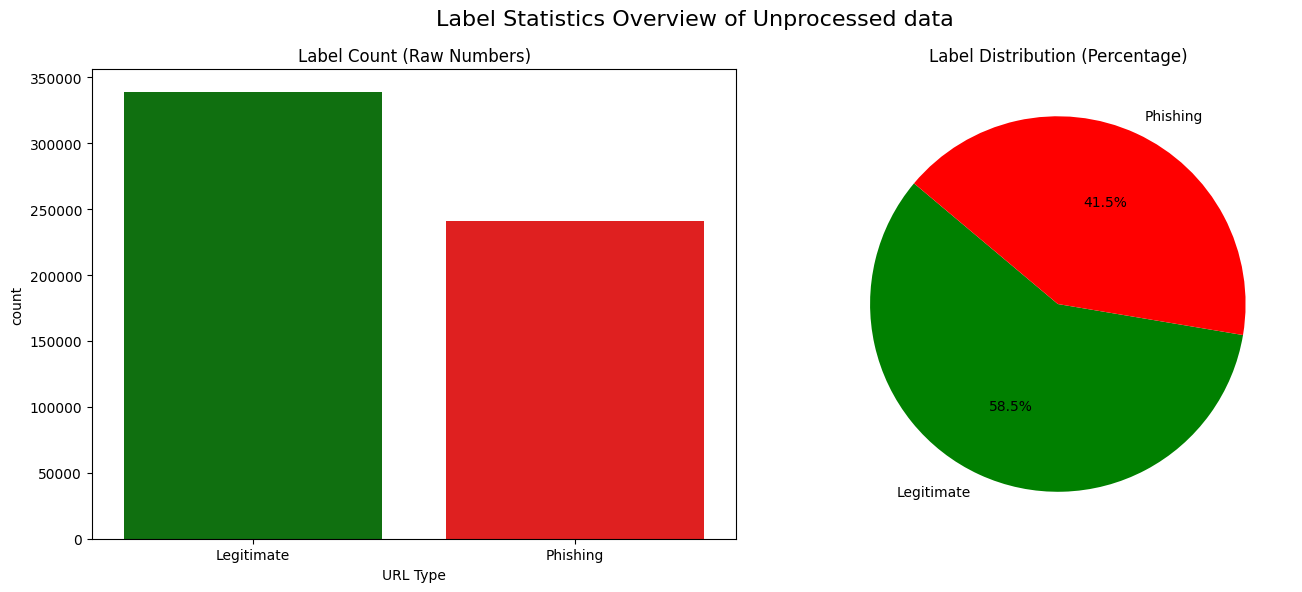

In [7]:
data_counts = df['label'].value_counts().sort_index() # Sort to ensure 0 is first, then 1
custom_labels = ['Legitimate','Phishing']
custom_palette = ['green','red'] # Red for 1 (Phish), Green for 0 (Legit)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='label', data=df, hue='label', palette=custom_palette, ax=ax[0], legend=False)
ax[0].set_title('Label Count (Raw Numbers)')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(custom_labels) # This changes 0/1 to Phishing/Legitimate
ax[0].set_xlabel('URL Type')

ax[1].pie(data_counts, 
          labels=custom_labels,
          autopct='%1.1f%%', 
          colors=custom_palette, 
          startangle=140)
ax[1].set_title('Label Distribution (Percentage)')

plt.suptitle('Label Statistics Overview of Unprocessed data', fontsize=16)
plt.tight_layout()
plt.savefig('./images/1_Label_Statistics_Overview_of_Unprocessed_data.png')
plt.show()

In [16]:
print(f'Number of phishing: {(df['label'] == 1).sum()}\nNumber of Legitimate: {(df['label'] == 0).sum()}')

Number of phishing: 240846
Number of Legitimate: 339074


In [8]:
df.describe()

,label,url_length,domain_length,hostname_length,path_length,first_dir_length,tld_length,tld_length_domain,url_depth,query_length,...,whois_success,domain_age_days,expiration_days,creation_year,domain_is_recent,domain_registered_before_2020,registrar_valid,name_servers_count,is_privacy_protected,whois_missing
count,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,...,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000,579920.000000
mean,0.415309,51.629570,8.630492,18.709791,19.353054,7.322879,3.028875,3.028875,1.521565,5.373081,...,0.931722,4457.843520,461.628414,1556.010976,0.223957,0.783548,0.727205,2.334808,0.010389,0.011803
std,0.492776,70.993632,4.383994,11.078410,31.477138,11.045024,1.089538,1.089538,2.976379,38.611224,...,0.252223,3933.424574,752.554920,840.192371,0.416894,0.411826,0.445396,1.852563,0.101397,0.108000
min,0.000000,12.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-7324.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,32.000000,6.000000,13.000000,5.000000,2.000000,2.000000,2.000000,1.000000,0.000000,...,1.000000,90.000000,8.000000,1995.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,41.000000,8.000000,16.000000,13.000000,6.000000,3.000000,3.000000,1.000000,0.000000,...,1.000000,4275.000000,212.000000,2005.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000
75%,1.000000,55.000000,11.000000,21.000000,24.000000,9.000000,3.000000,3.000000,2.000000,0.000000,...,1.000000,7781.000000,471.000000,2015.000000,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000
max,1.000000,25523.000000,63.000000,236.000000,4316.000000,1024.000000,16.000000,16.000000,334.000000,4471.000000,...,1.000000,15092.000000,30265.000000,2025.000000,1.000000,1.000000,1.000000,54.000000,1.000000,1.000000


## ***Cleaning the dataset***

#### ***Remove duplicate rows***

In [17]:
# remove duplicate rows
print(f'Before removal: {df.shape[0]}')
all_duplicates = df[df.duplicated(subset=['url'], keep=False)]
no_of_duplicate_rows = all_duplicates.shape[0]
print(f'Number of duplicates: {no_of_duplicate_rows} - {'No duplicates' if no_of_duplicate_rows == 0 else ''}')
df.drop_duplicates(subset=['url'], keep='first', inplace=True)
print(f'After Removal: {df.shape[0]}')

Before removal: 579920
Number of duplicates: 0 - No duplicates
After Removal: 579920


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 579920 entries, 0 to 579919
Data columns (total 76 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   url                            579920 non-null  str    
 1   label                          579920 non-null  int64  
 2   url_length                     579920 non-null  int64  
 3   domain_length                  579920 non-null  int64  
 4   hostname_length                579920 non-null  int64  
 5   path_length                    579920 non-null  int64  
 6   first_dir_length               579920 non-null  int64  
 7   tld_length                     579920 non-null  int64  
 8   tld_length_domain              579920 non-null  int64  
 9   url_depth                      579920 non-null  int64  
 10  query_length                   579920 non-null  int64  
 11  path_segments_count            579920 non-null  int64  
 12  num_digits                     579920 non

#### ***Feature extraction***
##### *URL features to be considered*
- ***length features***
    - url_length
    - domain_length
    - hostname_length
    - path_length
    - tld_length
    - query_length
- ***Count features***
    - num_digits   
    - num_letters
    - num_uppercase
    - num_lowercase
    - num_subdomains
    - num_dots
    - num_hyphen
    - num_at
    - num_dollars
    - num_percent
    - num_question
    - num_equal
    - num_hash
    - num_ampersand
    - num_underscore
    - num_slashes
    - num_params
- ***entropy features***
    - entropy_url
    - entropy_path
    - entropy_domain
    - entropy_query
- ***ratio features***
    - ratio_digits
    - ratio_letters
    - ratio_ uppercase
    - ratio_lowercase
- ***containment_features***
    - contains_login
    - contains_verify
    - contains_secure
    - contains_update
    - contains_bank
- ***Whois features (will use that of the original dataset)***
    - whois_success
    - domain_age_days
    - creation_year
- ***other featues***
    - is_ip_address
    - uses_https
    - has_www
    - unusual_double_slash
    - has_specials
    - is_shortened

##### ***Creating new dataset***
A new dataset will be created from the original one.\
the following columns will be retained
- url
- label
- whois_success
- domain_age_days
- creation_year

In [120]:
new_df = df[['url','label','whois_success','domain_age_days','creation_year']]
new_df.head()

,url,label,whois_success,domain_age_days,creation_year
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg1e0h2f/qiye,1,1.0,5484.0,2010.0
1,https://*f003.backblazeb2.com*/file/pesosi/home.html,1,0.0,0.0,0.0
2,http://0-docusign-secured-843439-1-srs09.replit.app/,1,1.0,0.0,0.0
3,http://0-olx.1850943.xyz/,1,1.0,272.0,2025.0
4,http://0.0.0.0forum.cryptonight.net,1,1.0,475.0,2024.0


In [43]:
# load url shorteners as a list
try:
    with open('shorteners.txt', 'r') as f:
        MY_SHORTENERS = {line.strip().lower() for line in f if line.strip()}
    print(f"Successfully loaded {len(MY_SHORTENERS)} shortener domains.")
except FileNotFoundError:
    print("Warning: shorteners.txt not found. IsShortened feature will be 0.")
    MY_SHORTENERS = set()

Successfully loaded 1479 shortener domains.


#### ***Url structure:*** *scheme://netloc/path?query#fragment*

In [119]:
# scheme://netloc/path?query#fragment

def check_is_ip(hostname):
    try:
        ipaddress.ip_address(hostname)
        return 1
    except:
        return 0
            
def extract_all_training_features(url:str):
    try:
        ext = tldextract.extract(url)
        domain = f'{ext.domain}.{ext.suffix}'
        url_features = urlparse(url)

        entropy(list(Counter(url).values()), base=2)
        
        pattern = r'[^a-zA-Z0-9\s]'
        features = {
            # length feature
            'url_length': len(url),
            'domain_length': len(domain),
            'hostname_length': len(url_features.hostname),
            'path_length': len(url_features.path),
            'tld_length': len(ext.suffix),
            'query_length': len(url_features.query),

            # Count features

            'num_digits': sum(c.isdigit() for c in url),
            'num_letters': sum(c.isalpha() for c in url),
            'num_uppercase': sum(1 for char in url if char.isupper()),
            'num_lowercase': sum(1 for char in url if char.islower()),
            'num_subdomains': len(ext.subdomain.split('.')) if ext.subdomain else 0,
            'num_dots': url.count('.'),
            'num_hyphen': url.count('-'),
            'num_at': url.count('@'),
            'num_percent': url.count('%'),
            'num_question': url.count('?'),
            'num_equal': url.count('='),
            'num_hash': url.count('#'),
            'num_ampersand': url.count('&'),
            'num_underscore': url.count('_'),
            'num_dollars': url.count('$'),
            'num_slashes': url.count('/'),
            'num_params': len(url_features.query.split('&')) if url_features.query else 0,

            # entropy features
            'entropy_url' : round(float(entropy(list(Counter(url).values()), base=2)), 2),
            'entropy_path': round(float(entropy(list(Counter(url_features.path).values()), base=2)), 2),
            'entropy_domain': round(float(entropy(list(Counter(domain).values()), base=2)), 2),
            'entropy_query': round(float(entropy(list(Counter(url_features.query).values()), base=2)), 2),

            # ratio features
            'ratio_digits': round(sum(c.isdigit() for c in url) / len(url),2),
            'ratio_letters': round(sum(c.isalpha() for c in url) / len(url),2),
            'ratio_ uppercase': round(sum(1 for char in url if char.isupper())/len(url),2),
            'ratio_lowercase': round(sum(1 for char in url if char.islower())/len(url),2),

            # containment_features
            'contains_login': 1 if any(w in url.lower() for w in ['access','', 'login', 'signin']) else 0,
            'contains_verify': 1 if any(w in url.lower() for w in ['confirm','verify','verification']) else 0,
            'contains_secure': 1 if any(w in url.lower() for w in ['secure', 'safe', 'security']) else 0,
            'contains_update': 1 if any(w in url.lower() for w in ['update', 'upgrade']) else 0,
            'contains_bank': 1 if any(w in url.lower() for w in ['bank', 'secure', 'login', 'signin', 'verify']) else 0,
            'contains_crypto': 1 if any(w in url.lower() for w in ['crypto', 'bit', 'coin', 'eth', 'blockchain']) else 0,
            'contains_pay': 1 if any(w in url.lower() for w in ['paypal', 'pay', 'wallet', 'checkout']) else 0,
            'contains_obfuscation': 1 if any(x in url for x in ['%%', 'hex', 'encoding']) else 0,
            
            #other features
            'has_specials': 1 if re.search(pattern, url) else 0,
            'is_ip_address':check_is_ip(hostname=url_features.hostname),
            'uses_https': 1 if url_features.scheme == 'https' else 0,
            'has_www' : 1 if url_features.hostname and url_features.hostname.startswith('www.') else 0,
            'unusual_double_slash': 1 if url.count("//") > 1 else 0,
            'is_shortened': 1 if domain in MY_SHORTENERS else 0,
        }
        return features
    except Exception as e:
        return e

extract_all_training_features('https://is.gd:8000/ipfs/qmMsw6iwtrv3yptvhbpmal9vua4ckdceyrw2twl1s6jh2ox?cmd=1&now=true#top')

{'url_length': 90,
 'domain_length': 5,
 'hostname_length': 5,
 'path_length': 53,
 'tld_length': 2,
 'query_length': 14,
 'num_digits': 13,
 'num_letters': 65,
 'num_uppercase': 1,
 'num_lowercase': 64,
 'num_subdomains': 0,
 'num_dots': 1,
 'num_hyphen': 0,
 'num_at': 0,
 'num_percent': 0,
 'num_question': 1,
 'num_equal': 2,
 'num_hash': 1,
 'num_ampersand': 1,
 'num_underscore': 0,
 'num_dollars': 0,
 'num_slashes': 4,
 'num_params': 2,
 'entropy_url': 5.1,
 'entropy_path': 4.8,
 'entropy_domain': 2.32,
 'entropy_query': 3.66,
 'ratio_digits': 0.14,
 'ratio_letters': 0.72,
 'ratio_ uppercase': 0.01,
 'ratio_lowercase': 0.71,
 'contains_login': 1,
 'contains_verify': 0,
 'contains_secure': 0,
 'contains_update': 0,
 'contains_bank': 0,
 'contains_crypto': 0,
 'contains_pay': 0,
 'contains_obfuscation': 0,
 'has_specials': 1,
 'is_ip_address': 0,
 'uses_https': 1,
 'has_www': 0,
 'unusual_double_slash': 0,
 'is_shortened': 1}

In [123]:
feature_df = new_df['url'].apply(extract_all_training_features).apply(pd.Series)

In [125]:
final_df = pd.concat([new_df, feature_df], axis=1)

In [126]:
final_df

,url,label,whois_success,domain_age_days,creation_year,url_length,domain_length,hostname_length,path_length,tld_length,...,contains_bank,contains_crypto,contains_pay,contains_obfuscation,has_specials,is_ip_address,uses_https,has_www,unusual_double_slash,is_shortened
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg1e0h2f/qiye,1,1.0,5484.0,2010.0,57.0,11.0,11.0,26.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,https://*f003.backblazeb2.com*/file/pesosi/home.html,1,0.0,0.0,0.0,52.0,5.0,22.0,22.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,http://0-docusign-secured-843439-1-srs09.replit.app/,1,1.0,0.0,0.0,52.0,10.0,44.0,1.0,3.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,http://0-olx.1850943.xyz/,1,1.0,272.0,2025.0,25.0,11.0,17.0,1.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,http://0.0.0.0forum.cryptonight.net,1,1.0,475.0,2024.0,35.0,15.0,28.0,0.0,3.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579915,https://zzzafjeiwsyb.bond,1,1.0,0.0,0.0,25.0,17.0,17.0,0.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
579916,https://zzzafjeiwsyb.bond/,1,1.0,0.0,0.0,26.0,17.0,17.0,1.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
579917,https://zzzsq.cn/eRDm1S/#/,1,0.0,0.0,0.0,26.0,8.0,8.0,8.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
579918,https://zzztube.com/,0,1.0,5132.0,2011.0,20.0,11.0,11.0,1.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [128]:
int_cols = [
    'whois_success', 'domain_age_days', 'creation_year',
    'url_length', 'domain_length', 'hostname_length', 'path_length', 'tld_length',
    'query_length', 'num_digits', 'num_letters', 'num_uppercase', 'num_lowercase',
    'num_subdomains', 'num_dots', 'num_hyphen', 'num_at', 'num_percent',
    'num_question', 'num_equal', 'num_hash', 'num_ampersand', 'num_underscore',
    'num_dollars', 'num_slashes', 'num_params', 'contains_login', 'contains_verify',
    'contains_secure', 'contains_update', 'contains_bank', 'contains_crypto',
    'contains_pay', 'contains_obfuscation', 'has_specials', 'is_ip_address',
    'uses_https', 'has_www', 'unusual_double_slash', 'is_shortened'
]

final_df[int_cols] = final_df[int_cols].astype(int)

In [130]:
final_df

,url,label,whois_success,domain_age_days,creation_year,url_length,domain_length,hostname_length,path_length,tld_length,...,contains_bank,contains_crypto,contains_pay,contains_obfuscation,has_specials,is_ip_address,uses_https,has_www,unusual_double_slash,is_shortened
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg1e0h2f/qiye,1,1,5484,2010,57,11,11,26,3,...,0,0,0,0,1,0,0,0,0,0
1,https://*f003.backblazeb2.com*/file/pesosi/home.html,1,0,0,0,52,5,22,22,0,...,0,0,0,0,1,0,1,0,0,0
2,http://0-docusign-secured-843439-1-srs09.replit.app/,1,1,0,0,52,10,44,1,3,...,1,0,0,0,1,0,0,0,0,0
3,http://0-olx.1850943.xyz/,1,1,272,2025,25,11,17,1,3,...,0,0,0,0,1,0,0,0,0,0
4,http://0.0.0.0forum.cryptonight.net,1,1,475,2024,35,15,28,0,3,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579915,https://zzzafjeiwsyb.bond,1,1,0,0,25,17,17,0,4,...,0,0,0,0,1,0,1,0,0,0
579916,https://zzzafjeiwsyb.bond/,1,1,0,0,26,17,17,1,4,...,0,0,0,0,1,0,1,0,0,0
579917,https://zzzsq.cn/eRDm1S/#/,1,0,0,0,26,8,8,8,2,...,0,0,0,0,1,0,1,0,0,0
579918,https://zzztube.com/,0,1,5132,2011,20,11,11,1,3,...,0,0,0,0,1,0,1,0,0,0


In [131]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 579920 entries, 0 to 579919
Data columns (total 50 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   url                   579920 non-null  str    
 1   label                 579920 non-null  int64  
 2   whois_success         579920 non-null  int64  
 3   domain_age_days       579920 non-null  int64  
 4   creation_year         579920 non-null  int64  
 5   url_length            579920 non-null  int64  
 6   domain_length         579920 non-null  int64  
 7   hostname_length       579920 non-null  int64  
 8   path_length           579920 non-null  int64  
 9   tld_length            579920 non-null  int64  
 10  query_length          579920 non-null  int64  
 11  num_digits            579920 non-null  int64  
 12  num_letters           579920 non-null  int64  
 13  num_uppercase         579920 non-null  int64  
 14  num_lowercase         579920 non-null  int64  
 15  num_subdoma

#### ***Resolving class imbalance***

In [133]:
df_phish_all = final_df[final_df['label'] == 1]
df_legit_all = final_df[final_df['label'] == 0]

df_phish_sample = df_phish_all.sample(n=240000, random_state=42) # random 240000 phishing url datasets
df_legit_sample = df_legit_all.sample(n=240000, random_state=42)

phish_leftovers = df_phish_all.drop(df_phish_sample.index) # leftover phishing url datasets
legit_leftovers = df_legit_all.drop(df_legit_sample.index) # leftover legit url datasets

df_leftovers = pd.concat([phish_leftovers, legit_leftovers]) # combination of both leftovers
df_balanced = pd.concat([df_phish_sample, df_legit_sample]).sample(frac=1, random_state=42) 

df_balanced.to_csv('./datasets/final_480_000_balanced_datasets.csv', index=False)
df_leftovers.to_csv('./datasets/final_leftover_34_370_unbalanced_datasets.csv', index=False)

print(f"Balanced file saved: {len(df_balanced)} rows")
print(f"Leftover file saved: {len(df_leftovers)} rows")

Balanced file saved: 480000 rows
Leftover file saved: 99920 rows


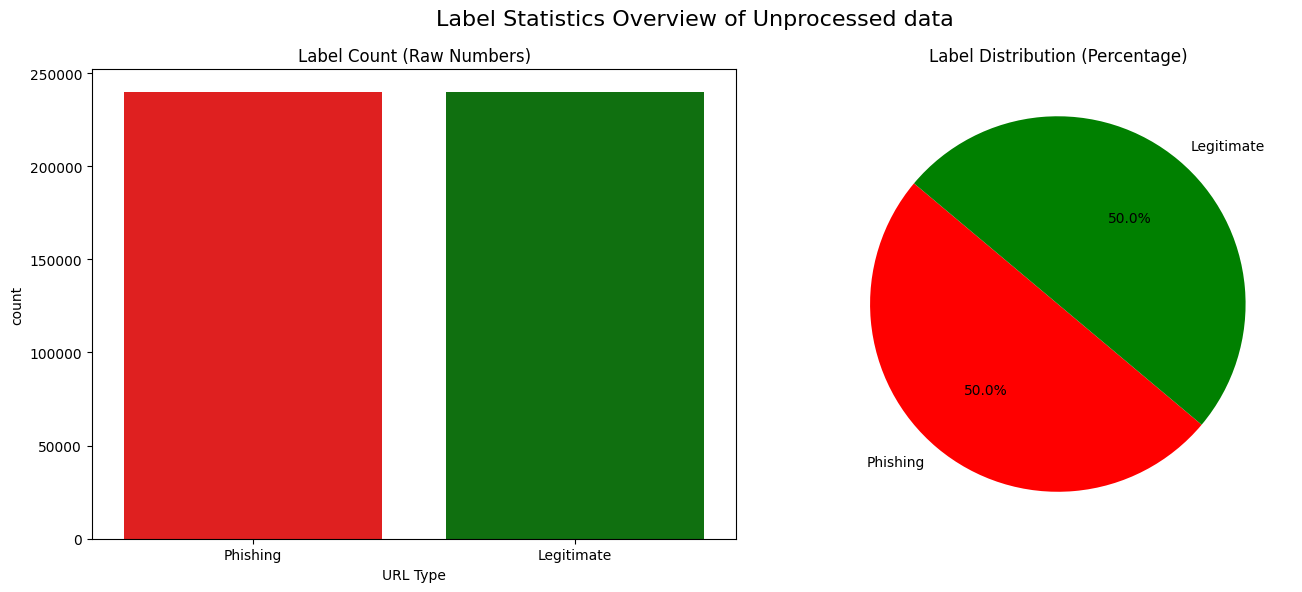

In [138]:
data_counts = df_balanced['label'].value_counts().sort_index() # Sort to ensure 0 is first, then 1
custom_labels = ['Phishing','Legitimate']
custom_palette = ['red','green'] # Red for 1 (Phish), Green for 0 (Legit)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='label', data=df_balanced, hue='label', palette=custom_palette, ax=ax[0], legend=False)
ax[0].set_title('Label Count (Raw Numbers)')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(custom_labels) # This changes 0/1 to Phishing/Legitimate
ax[0].set_xlabel('URL Type')

ax[1].pie(data_counts, 
          labels=custom_labels,
          autopct='%1.1f%%', 
          colors=custom_palette, 
          startangle=140)
ax[1].set_title('Label Distribution (Percentage)')

plt.suptitle('Label Statistics Overview of Unprocessed data', fontsize=16)
plt.tight_layout()
plt.savefig('./images/2_Label_Statistics_Overview_of_Processed_data.png')
plt.show()

In [136]:
print(f'Number of phishing: {(df_balanced['label'] == 1).sum()}\nNumber of Legitimate: {(df_balanced['label'] == 0).sum()}')

Number of phishing: 240000
Number of Legitimate: 240000
